In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


📌 This project detects fake news using machine learning with logistic regression.

📌 We used TfidfVectorizer to convert text to vectors.

✅ “Achieved ~93% accuracy.”


In [7]:
# 1. Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 2. Load Dataset
true_df = pd.read_csv('/content/drive/MyDrive/True.csv')
fake_df = pd.read_csv('/content/drive/MyDrive/Fake.csv')

# 3. Label the data
true_df['label'] = 'REAL'
fake_df['label'] = 'FAKE'

# 4. Merge and shuffle
df = pd.concat([true_df, fake_df])
df = df.sample(frac=1).reset_index(drop=True)

# 5. Split data
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Vectorize
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 7. Train Model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# 8. Predict & Evaluate
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9839643652561247


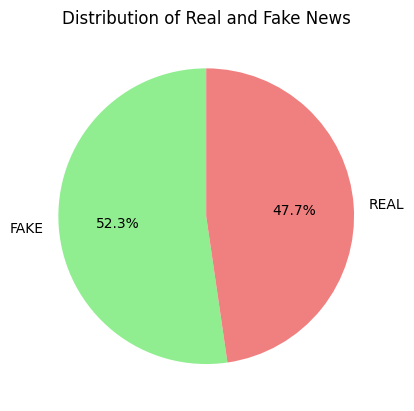

In [8]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
plt.title('Distribution of Real and Fake News')
plt.ylabel('')
plt.show()

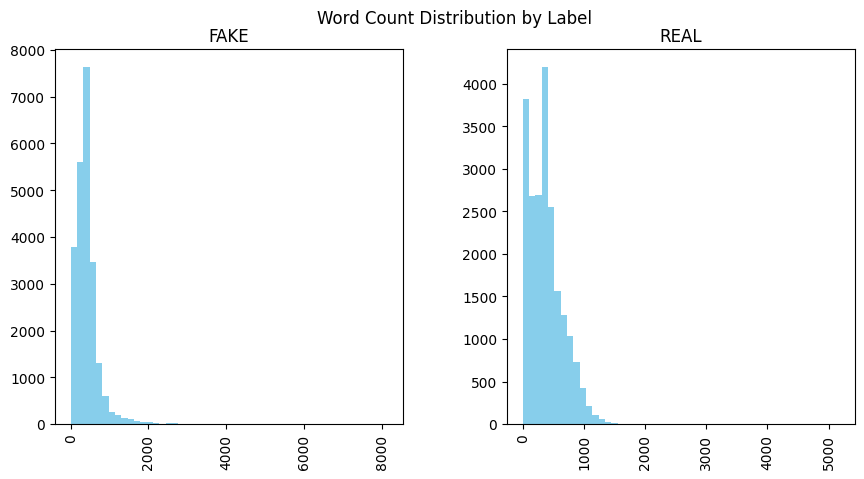

In [10]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
df.hist(column='text_length', by='label', bins=50, figsize=(10,5), color='skyblue')
plt.suptitle("Word Count Distribution by Label")
plt.show()

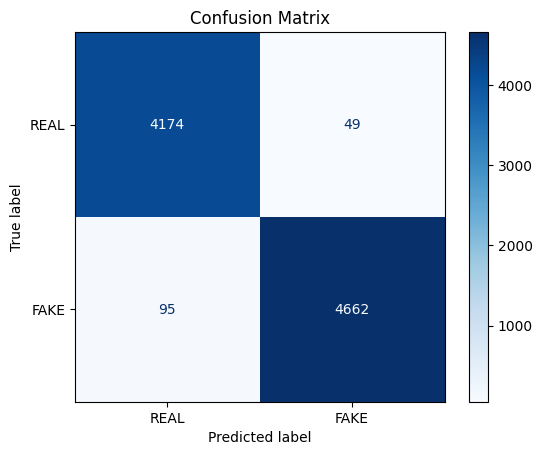

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=['REAL', 'FAKE'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['REAL', 'FAKE'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

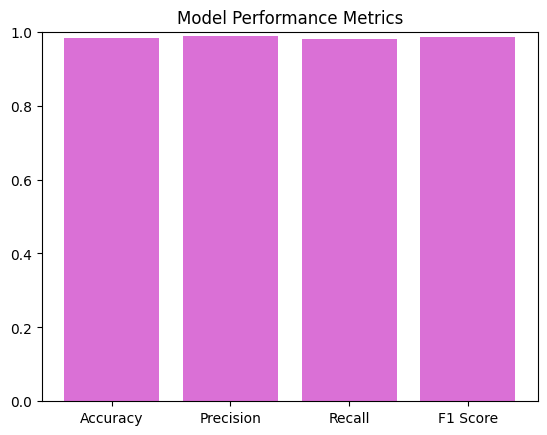

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, pos_label='FAKE')
recall = recall_score(y_test, y_pred, pos_label='FAKE')
f1 = f1_score(y_test, y_pred, pos_label='FAKE')
accuracy = accuracy_score(y_test, y_pred)

metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
plt.bar(metrics.keys(), metrics.values(), color='orchid')
plt.title('Model Performance Metrics')
plt.ylim(0, 1)
plt.show()